<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-50-adaboost-intuition-implementation?scriptVersionId=351093786" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🚀 ML 50 — AdaBoost | Intuition & Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


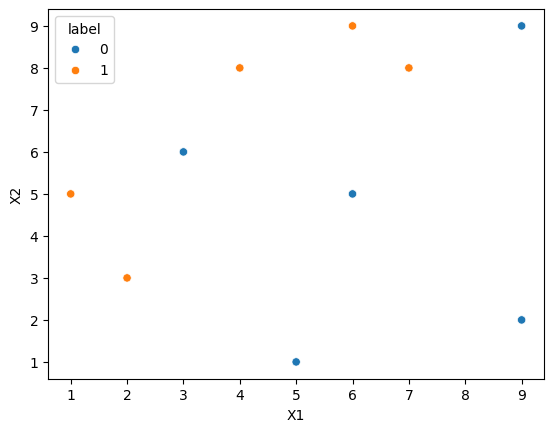

In [3]:
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])
plt.show()

In [4]:
df['weights'] = 1/df.shape[0]
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [5]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth=1)

X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

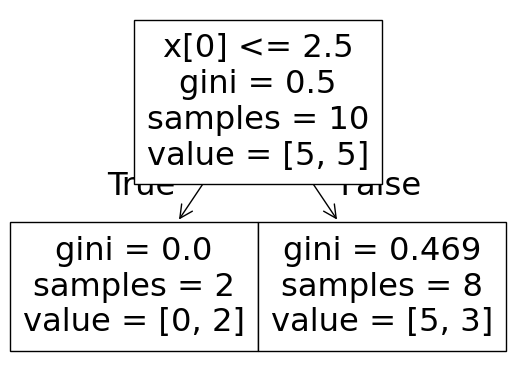

In [6]:
from sklearn.tree import plot_tree
plot_tree(dt1)
plt.show()

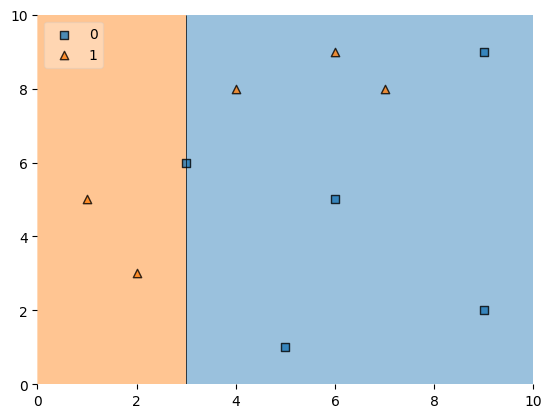

In [7]:
plot_decision_regions(X, y, clf=dt1, legend=2)
plt.show()

In [8]:
df['y_pred'] = dt1.predict(X)
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [9]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [10]:
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [11]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [12]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [13]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [14]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [15]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])
     
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']
     
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [16]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [17]:
index_values = create_new_dataset(df)
index_values

[9, 4, 9, 1, 3, 1, 8, 4, 2, 7]

In [18]:
second_df = df.iloc[index_values,[0,1,2,3]]
second_df

,X1,X2,label,weights
9,9,2,0,0.1
4,5,1,0,0.1
9,9,2,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1
8,9,9,0,0.1
4,5,1,0,0.1
2,3,6,0,0.1
7,7,8,1,0.1


In [19]:
dt2 = DecisionTreeClassifier(max_depth=1)
     

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
     

dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

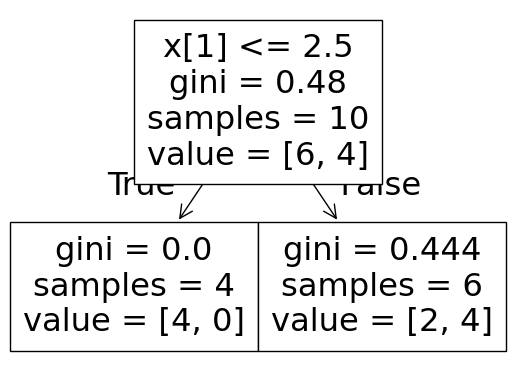

In [20]:
plot_tree(dt2)
plt.show()

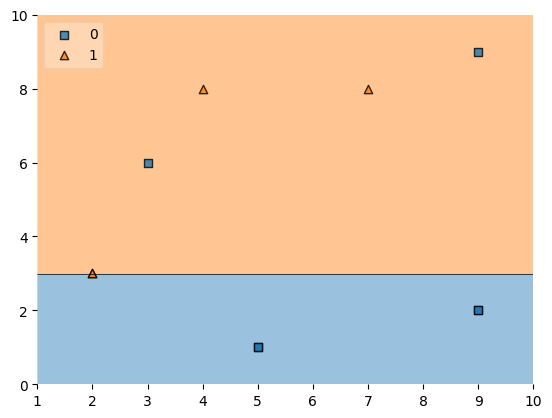

In [21]:
plot_decision_regions(X, y, clf=dt2, legend=2)
plt.show()

In [22]:
second_df['y_pred'] = dt2.predict(X)
     

second_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
4,5,1,0,0.1,0
9,9,2,0,0.1,0
1,2,3,1,0.1,1
3,4,8,1,0.1,1
1,2,3,1,0.1,1
8,9,9,0,0.1,1
4,5,1,0,0.1,0
2,3,6,0,0.1,1
7,7,8,1,0.1,1


In [23]:
alpha2 = calculate_model_weight(0.1)
     

alpha2

np.float64(1.0986122886681098)

In [24]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)
     

second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)
     

second_df

,X1,X2,label,weights,y_pred,updated_weights
9,9,2,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
9,9,2,0,0.1,0,0.033622
1,2,3,1,0.1,1,0.033622
3,4,8,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
8,9,9,0,0.1,1,0.297427
4,5,1,0,0.1,0,0.033622
2,3,6,0,0.1,1,0.297427
7,7,8,1,0.1,1,0.033622


In [25]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()
     

second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
9,9,2,0,0.1,0,0.033622,0.038922
4,5,1,0,0.1,0,0.033622,0.038922
9,9,2,0,0.1,0,0.033622,0.038922
1,2,3,1,0.1,1,0.033622,0.038922
3,4,8,1,0.1,1,0.033622,0.038922
1,2,3,1,0.1,1,0.033622,0.038922
8,9,9,0,0.1,1,0.297427,0.344313
4,5,1,0,0.1,0,0.033622,0.038922
2,3,6,0,0.1,1,0.297427,0.344313
7,7,8,1,0.1,1,0.033622,0.038922


In [26]:
second_df['nomalized_weights'].sum()

np.float64(0.9999999999999999)

In [27]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
     

second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']
     

second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
9,9,2,0,0.1,0,0.038922,0.000000,0.038922
4,5,1,0,0.1,0,0.038922,0.038922,0.077843
9,9,2,0,0.1,0,0.038922,0.077843,0.116765
1,2,3,1,0.1,1,0.038922,0.116765,0.155687
3,4,8,1,0.1,1,0.038922,0.155687,0.194608
1,2,3,1,0.1,1,0.038922,0.194608,0.233530
8,9,9,0,0.1,1,0.344313,0.233530,0.577843
4,5,1,0,0.1,0,0.038922,0.577843,0.616765
2,3,6,0,0.1,1,0.344313,0.616765,0.961078
7,7,8,1,0.1,1,0.038922,0.961078,1.000000


In [28]:
index_values = create_new_dataset(second_df)
     

third_df = second_df.iloc[index_values,[0,1,2,3]]
     

third_df

,X1,X2,label,weights
9,9,2,0,0.1
7,7,8,1,0.1
9,9,2,0,0.1
9,9,2,0,0.1
4,5,1,0,0.1
2,3,6,0,0.1
1,2,3,1,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1


In [29]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

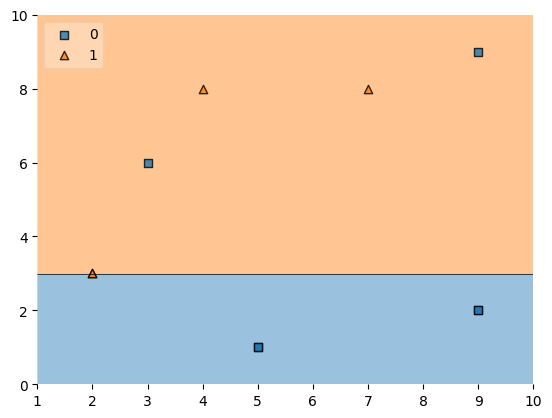

In [30]:
plot_decision_regions(X, y, clf=dt3, legend=2)
plt.show()

In [31]:
third_df['y_pred'] = dt3.predict(X)
     

third_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
7,7,8,1,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,1
4,5,1,0,0.1,1
2,3,6,0,0.1,1
1,2,3,1,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,1
9,9,2,0,0.1,1


In [32]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [33]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


## Prediction

In [34]:
query = np.array([1,5]).reshape(1,2)

In [35]:
dt1.predict(query)

array([1])

In [36]:
dt2.predict(query)

array([1])

In [37]:
dt3.predict(query)

array([1])

In [38]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [39]:
np.sign(1.09)

np.float64(1.0)

# Bagging VS Boosting

1. Type of Model Used
2. Sequential VS Parallel
3. Weightage of Base Learners